Use the Intel Image Classification dataset.
https://www.kaggle.com/datasets/puneet6060/intel-image-classification
The dataset contains natural scene images belonging to six classes:
• buildings
• forest
• glacier
• mountain
• sea
• street
Use the seg_train and seg_test folders. The seg_pred folder is not required.
Use the seg_train dataset for training. Split it into training (80%) and validation (20%) sets.
After training the model, evaluate its performance using the seg_test dataset.
1. Dataset Preparation
Prepare the dataset, including:
1. Load the dataset.
2. Resize images to 150 × 150 if they are not already 150 × 150.
3. Normalize pixel values to [0,1].
4. Split the seg_train dataset into training and validation datasets.
Display several example images from the dataset and report:
• Number of training samples
• Number of validation samples
• Number of test samples
• Number of classes
2. Build a CNN Model
Build a Convolutional Neural Network. The network must include at least:
• 1 Conv2D layer
• 1 MaxPooling layer
• 1 Flatten layer
• 1 Dense layer
Train the model. Report the test accuracy on the seg_test dataset.
Internal
3. Modify the CNN Architecture
Modify the CNN architecture. For example, you may:
• Add additional Conv2D layers
• Add additional MaxPooling layers
• Change the number of filters
Train the model. Report the test accuracy on the seg_test dataset.
4. Data Augmentation
Apply data augmentation to the training dataset only. For example:
• horizontal flip
• rotation
• zoom
• brightness adjustment
Train the model. Report the test accuracy on the seg_test dataset.
5. Regularization
Apply regularization techniques such as Dropout layers or EarlyStopping during training. Train the
model. Report the test accuracy on the seg_test dataset.
6. Report
Create a short report (1 page) including:
1. Model architecture diagrams
2. Training settings (e.g., epochs, optimizer, loss function)
3. Data augmentation methods used
4. Regularization methods used
5. Compare the test accuracy of the models in Tasks 2–5.
Submission
Submit your source code and report to Canvas and demonstrate your work to the tutor during the
lab session.



In [113]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import os   
from tensorflow.keras import layers, models, datasets

In [114]:
if not print(os.listdir("./data/archive/seg_train")):
    print("train dir not found")

if not print(os.listdir("./data/archive/seg_test")):
    print("test dir not found")

train_dataset = tf.keras.utils.image_dataset_from_directory(
    "./data/archive/seg_train/seg_train",
    image_size=(150, 150),
    label_mode='categorical'
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    "./data/archive/seg_test/seg_test",
    image_size=(150, 150),
    label_mode='categorical'
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    "./data/archive/seg_train/seg_train",
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(150, 150),
    label_mode='categorical'
)

class_names = test_dataset.class_names
print(class_names)

['seg_train']
train dir not found
['seg_test']
test dir not found
Found 14034 files belonging to 6 classes.
Found 3000 files belonging to 6 classes.
Found 14034 files belonging to 6 classes.
Using 2806 files for validation.
['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


In [115]:
train_dataset = train_dataset.map(lambda x, y: (x / 255.0, y))
test_dataset = test_dataset.map(lambda x, y: (x / 255.0, y))

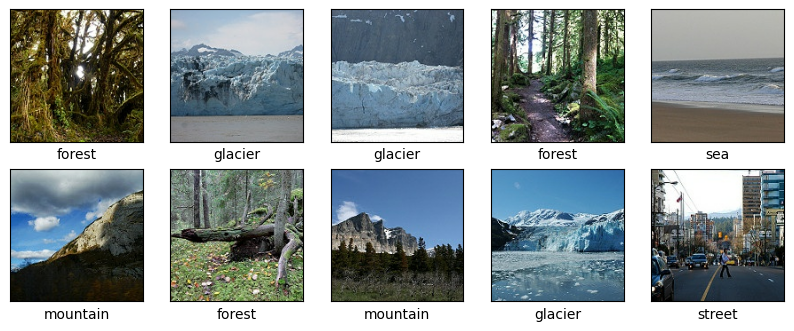

In [116]:
plt.figure(figsize=(10, 10))

for images, labels in train_dataset.take(1):
    for i in range(10):
        plt.subplot(5, 5, i + 1)
        plt.xticks([])
        plt.yticks([]),
        plt.grid(False)
        plt.imshow(images[i].numpy())

        label_index = labels[i].numpy().argmax()
        plt.xlabel(class_names[label_index])

plt.show()

In [117]:
(train_images, train_labels) = next(iter(train_dataset))
(test_images, test_labels) = next(iter(test_dataset))
print("Train images shape:", train_images.shape)
print("Train labels shape:", train_labels.shape)
print("Test images shape:", test_images.shape)
print("Test labels shape:", test_labels.shape)

Train images shape: (32, 150, 150, 3)
Train labels shape: (32, 6)
Test images shape: (32, 150, 150, 3)
Test labels shape: (32, 6)


In [118]:
train_count = len(train_dataset)
test_count = len(test_dataset)
val_count = len(val_dataset)
print(f"train count: {train_count}, test count: {test_count}, val count: {val_count}")

train count: 439, test count: 94, val count: 88


In [119]:
model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)))
model.add(layers.MaxPool2D(2, 2))
model.add(layers.Flatten())
model.add(layers.Dense(6, activation='softmax'))
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy', 
    metrics=['accuracy']
)

/Users/finnerty/Documents/Swinburne/FinalSem/MachineSystems/LAB04/env/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [120]:
model.summary()

Model: "sequential_38"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_40 (Conv2D)              │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_40 (MaxPooling2D) │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_23 (Flatten)            │ (None, 175232)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 6)              │     1,051,398 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,052,294 (4.01 MB)

 Trainable params: 1,052,294 (4.01 MB)

 Non-trainable params: 0 (0.00 B)

In [121]:
history = model.fit(
    train_dataset, 
    epochs=10, 
    validation_data=val_dataset
)

Epoch 1/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 16s 36ms/step - accuracy: 0.6347 - loss: 1.1077 - val_accuracy: 0.8033 - val_loss: 61.4961
Epoch 2/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 17s 39ms/step - accuracy: 0.8072 - loss: 0.5608 - val_accuracy: 0.8186 - val_loss: 54.0870
Epoch 3/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 18s 41ms/step - accuracy: 0.9029 - loss: 0.3076 - val_accuracy: 0.8820 - val_loss: 36.0685
Epoch 4/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 19s 44ms/step - accuracy: 0.9545 - loss: 0.1737 - val_accuracy: 0.9387 - val_loss: 16.6504
Epoch 5/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 25s 56ms/step - accuracy: 0.9726 - loss: 0.1166 - val_accuracy: 0.9590 - val_loss: 17.3604
Epoch 6/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 33s 75ms/step - accuracy: 0.9805 - loss: 0.0863 - val_accuracy: 0.9544 - val_loss: 19.5277
Epoch 7/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 37s 83ms/step - accuracy: 0.9861 - loss: 0.0709 - val_accuracy: 0.9822 - val_loss: 7.6759
Epoch 8/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 34s 78ms/step - accuracy: 0.9848 - loss: 0.0

In [122]:
test_loss, test_accuracy = model.evaluate(test_dataset)
print(f"accuracy: {test_accuracy}, loss: {test_loss}")

94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.6937 - loss: 1.4099
accuracy: 0.6936666369438171, loss: 1.409929871559143


In [123]:
model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)))
model.add(layers.MaxPool2D(2, 2))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPool2D(2, 2))
model.add(layers.Flatten())
model.add(layers.Dense(6, activation='softmax'))
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy', 
    metrics=['accuracy']
)
model.summary()

Model: "sequential_39"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_41 (Conv2D)              │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_41 (MaxPooling2D) │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_42 (Conv2D)              │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_42 (MaxPooling2D) │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_24 (Flatten)            │ (None, 82944)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 6)              │       497,670 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 517,062 (1.97 MB)

 Trainable params: 517,062 (1.97 MB)

 Non-trainable params: 0 (0.00 B)

In [124]:
history = model.fit(
    train_dataset, 
    epochs=10, 
    validation_data=val_dataset
)

Epoch 1/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 78s 177ms/step - accuracy: 0.6342 - loss: 0.9817 - val_accuracy: 0.7448 - val_loss: 75.4982
Epoch 2/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 76s 174ms/step - accuracy: 0.7638 - loss: 0.6617 - val_accuracy: 0.7776 - val_loss: 68.8596
Epoch 3/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 74s 168ms/step - accuracy: 0.8261 - loss: 0.5058 - val_accuracy: 0.8182 - val_loss: 55.6575
Epoch 4/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 74s 170ms/step - accuracy: 0.8831 - loss: 0.3448 - val_accuracy: 0.8571 - val_loss: 44.8791
Epoch 5/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 73s 167ms/step - accuracy: 0.9277 - loss: 0.2205 - val_accuracy: 0.9230 - val_loss: 22.6619
Epoch 6/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 74s 168ms/step - accuracy: 0.9559 - loss: 0.1429 - val_accuracy: 0.9237 - val_loss: 28.8193
Epoch 7/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 69s 157ms/step - accuracy: 0.9709 - loss: 0.1017 - val_accuracy: 0.9180 - val_loss: 34.0838
Epoch 8/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 74s 169ms/step - accuracy: 0.9823 - 

In [125]:
test_loss, test_accuracy = model.evaluate(test_dataset)
print(f"accuracy: {test_accuracy}, loss: {test_loss}")

94/94 ━━━━━━━━━━━━━━━━━━━━ 4s 47ms/step - accuracy: 0.7313 - loss: 1.5228
accuracy: 0.731333315372467, loss: 1.5228159427642822


In [126]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    # layers.RandomRotation(0.05),
    # layers.RandomZoom(0.05),
    # layers.RandomBrightness(0.05)
])

model = tf.keras.Sequential([
    layers.Input(shape=(150, 150, 3)),
    data_augmentation,
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPool2D(2, 2),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPool2D(2, 2),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(6, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_41"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_40 (Sequential)      │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_43 (Conv2D)              │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_43 (MaxPooling2D) │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_44 (Conv2D)              │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_44 (MaxPooling2D) │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_25 (Flatten)            │ (None, 82944)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 128)            │    10,616,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,637,126 (40.58 MB)

 Trainable params: 10,637,126 (40.58 MB)

 Non-trainable params: 0 (0.00 B)

In [127]:
model.fit(train_dataset,
          epochs=10,
          validation_data=val_dataset)

Epoch 1/10
 17/439 ━━━━━━━━━━━━━━━━━━━━ 1:19 189ms/step - accuracy: 0.2366 - loss: 2.9302

KeyboardInterrupt: 

In [ ]:
test_loss, test_accuracy = model.evaluate(test_dataset)
print(f"accuracy: {test_accuracy}, loss: {test_loss}")

94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.8000 - loss: 0.8658
accuracy: 0.800000011920929, loss: 0.8657810688018799


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
])

model = tf.keras.Sequential([
    layers.Input(shape=(150, 150, 3)),
    data_augmentation,
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPool2D(2, 2),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPool2D(2, 2),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(6, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
model.fit(
    train_dataset,
    epochs=20,
    validation_data=val_dataset,
    callbacks=[early_stopping]
)

Epoch 1/20
439/439 ━━━━━━━━━━━━━━━━━━━━ 52s 117ms/step - accuracy: 0.6429 - loss: 0.9504 - val_accuracy: 0.6643 - val_loss: 116.9623
Epoch 2/20
439/439 ━━━━━━━━━━━━━━━━━━━━ 63s 144ms/step - accuracy: 0.7731 - loss: 0.6319 - val_accuracy: 0.7363 - val_loss: 78.4679
Epoch 3/20
439/439 ━━━━━━━━━━━━━━━━━━━━ 94s 215ms/step - accuracy: 0.8306 - loss: 0.4804 - val_accuracy: 0.7897 - val_loss: 62.1703
Epoch 4/20
439/439 ━━━━━━━━━━━━━━━━━━━━ 81s 185ms/step - accuracy: 0.8685 - loss: 0.3846 - val_accuracy: 0.7470 - val_loss: 89.4137
Epoch 5/20
439/439 ━━━━━━━━━━━━━━━━━━━━ 78s 178ms/step - accuracy: 0.9093 - loss: 0.2790 - val_accuracy: 0.7684 - val_loss: 102.2890
Epoch 6/20
439/439 ━━━━━━━━━━━━━━━━━━━━ 79s 179ms/step - accuracy: 0.9336 - loss: 0.2027 - val_accuracy: 0.7819 - val_loss: 102.9105


In [ ]:
test_accuracy, test_loss = model.evaluate(test_dataset)
print(f"accuracy: {test_accuracy}, loss: {test_loss}")

94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.7967 - loss: 0.5667
accuracy: 0.5667119026184082, loss: 0.79666668176651


<h2>Training Settings</h2>
<p>Im using obviously using the train_dataset for fitting the model and am comparing it to the val_dataset, when i run the actual evaluation for each model itteration i am using the test_dataset to get the accuracy of each model itteration. Im using 10 epochs - i could use more but limitations of using MACOS resulting in using less epochs due to GPU power, as I belive Mac uses CPU</p>
<h2>Data Augmentation</h2>
<p>By far the most interesting results, I changed the augmentation layer a number of times and reconfigured things (Rotation, Zoom, Brightness) but i kept getting accuracy scores of 
10.7% but when considering 6 / 100, kind of leads me to believe the model is more or less guessing due to it being a weak itteration of a CNN, for that reason i removed those augmentation metrics and only kept the random horizontal. Keeping only one of these configurables resulted in getting a higher accuracy score making it a feasable addition to the model</p>
<h2>Regularzation Methods</h2>
To test the methods, I increased the number of epochs as I used early_stopping to moniter val_loss, meaning if progress stalls it exits training to avoid overfitting the model, if val_loss gets greater the model ceases training. patience is used to detect the difference within 3 epochs meaning if the value does not get better in the previous 3 itterations exit training. following the patience is the restore best weight field, this is here so when the model starts to decline it will not use the itteration in which it started to fail, the fitted model will be the "best" or lowest val_loss before the decline (will go back to a previous itteration). Throughout multiple tests with 20 epochs, the model generally exits around itteration 6-8.
<h2>Accuracy Scores</h2>
<p>
the scores are as follows
<ul>
    <li>itt 1: accuracy: 0.6937 - loss: 1.4099
    <li>itt 2: accuracy: 0.7313 - loss: 1.5228
    <li>itt 3: accuracy: 0.8000 - loss: 0.8658
    <li>itt 4: accuracy: 0.7967 - loss: 0.5667
</ul>
</p>